In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from quantum_logical.operators import selective_destroy
from scipy.optimize import curve_fit

In [2]:
# generating parameters and creating initial state
T1 = 50
T2 = 25
N = 5
dim = 2
trotter_dt = .02
psi0 = qt.tensor((qt.basis(dim, 1)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.basis(dim, 1)
rho0 = psi0 * psi0.dag()
amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
trotter = TrotterGroup(
    continuous_operators=[amp_damp_channel, phase_damp_channel],
    trotter_dt=trotter_dt,
)


# qt.Qobj(amp_damp_channel._create_single_qubit_operators(T1=1)[1])
# identity = qt.qeye(dim ** N)

In [3]:
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

z_gate = qt.Qobj([[1, 0], [0, -1]])

hada = 1/np.sqrt(2) * qt.Qobj([[1, 1], [1, -1]])

hada_layer = qt.tensor(hada, hada, hada, qt.qeye(dim), qt.qeye(dim))

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_54038/2090992508.py:2: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_54038/2090992508.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_54038/2090992508.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instea

In [4]:
# creating the initial state and encoding it 
psi0 = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

In [5]:
# store the states and the fidelities that come out
states = []
fids = []

In [6]:
# run the circuit 
initial_time = .34
initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
for i in range(len(initial_state_relax)):
    a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
    states.append(hada_layer * initial_state_relax[i] * hada_layer.dag()) # storing the state in the computational basis 
    fids.append(qt.fidelity(a, rho_encoded_traced))

# now apply the cnots to the circuit 
cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

rho_hada_pre_cnot = hada_layer * initial_state_relax[-1] * hada_layer.dag()

syndrome_time = .02
after_syndrome_extraction = trotter.apply(rho_hada_pre_cnot, duration= syndrome_time, discrete_unitary=cnot_gate_overall)
for i in range(len(after_syndrome_extraction)):
    a = hada_layer * after_syndrome_extraction[i] * hada_layer.dag() # need to do this in order to get the right fidelity in the correct basis 
    a = qt.ptrace(a, [0, 1, 2])
    states.append(after_syndrome_extraction[i])
    fids.append(qt.fidelity(a, rho_encoded_traced))

In [7]:
# projective measurement 
projection_operator_00 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))
projection_operator_01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))
projection_operator_10 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())) 
projection_operator_11 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))

In [8]:
# apply the recovery gate
# measurement step is instantaneous 
rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

# now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
# correction_operators
r00 = qt.tensor(qt.qeye(dim ** N))
r01 = qt.Qobj((qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim ** 3))).full())
r10 = qt.Qobj((qt.tensor(z_gate, qt.qeye(dim ** 4))).full())
r11 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.qeye(dim ** 2))).full())

In [9]:
# recovery algorithm
correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
                 r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
                 r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
                 r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
)

recovery_time = .04

# putting the states in the hadamard basis 
rho00 = hada_layer * rho00 * hada_layer.dag()
rho01 = hada_layer * rho01 * hada_layer.dag()
rho10 = hada_layer * rho10 * hada_layer.dag()
rho11 = hada_layer * rho11 * hada_layer.dag()
# measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
# states.extend(recovery1)
# fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

# have to add them back to get the overall density matrix 
for i in range(len(recovery1)):
    total_state = (np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag()) * recovery1[i] + 
                   np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag()) * recovery2[i] + 
                   np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag()) * recovery3[i] + 
                   np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag()) * recovery4[i])
    total_state_normal = total_state / np.trace(total_state)
    total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
    fids.append(qt.fidelity(total_state_trace, rho_encoded_traced))
    total_state_normal = hada_layer * total_state_normal * hada_layer.dag() # doing this in order to put the state in the computational basis 
    states.append(total_state_normal)

total_time = recovery_time + syndrome_time + initial_time

/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


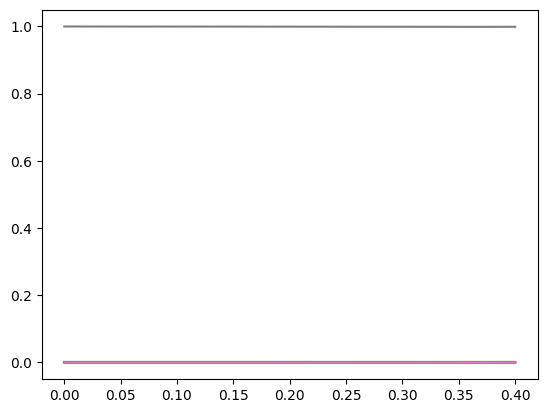

In [10]:
# trace out the ancillas
state_new = []
for i in range(len(states)):
    state_new.append(qt.ptrace(states[i], [0, 1, 2]))

time = np.linspace(0, total_time, len(states))

# graph the results
fig, ax = plt.subplots()
for i in range(dim ** 3):
    data = []
    for j in range(len(state_new)):
        data.append(state_new[j][i, i])
    ax.plot(time, data)

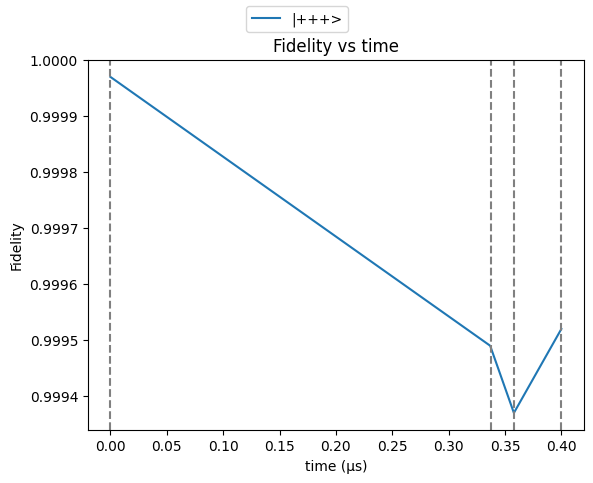

In [11]:
# fidelity plots 
fig, ax = plt.subplots()
ax.plot(time, fids, label = "|+++>")

ax.set_title("Fidelity vs time")
ax.set_ylabel("Fidelity")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

stages = [0,.338, .358, .4]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

In [12]:
fids[-1]

0.9995202338133631

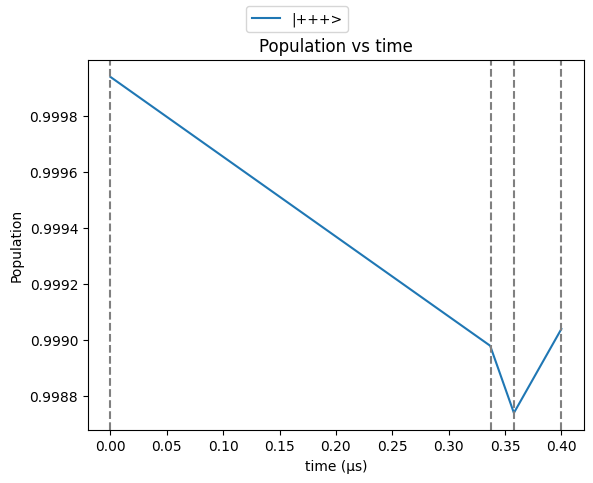

In [13]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_new)):
    data.append(state_new[i][7, 7])
ax.plot(time, data, label = "|+++>")

ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

stages = [0,.338, .358, .4]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

In [14]:
# creating the initial state and encoding it 
psi0 = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

In [15]:
# build the basic experiment first for regular detection
compare_state = []
compare_fids = []
total_time = 500
# rho_encoded_1 = hada_layer * rho_encoded * hada_layer.dag()
rho_plot = trotter.apply(rho_encoded, duration=total_time, discrete_unitary=qt.qeye(dim  ** N))
for i in range(len(rho_plot)):
    # a = hada_layer * rho_plot[i] * hada_layer.dag()
    a = qt.ptrace(rho_plot[i], [0, 1, 2])
    # a = qt.ptrace(a, [0, 1, 2])
    compare_state.append(a)
    compare_fids.append(qt.fidelity(a, rho_encoded_traced))

In [16]:
compare_state[0]

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.12502999 -0.125015   -0.125015    0.125      -0.125015    0.125
   0.125      -0.124985  ]
 [-0.125015    0.12501     0.125      -0.124995    0.125      -0.124995
  -0.124985    0.12498   ]
 [-0.125015    0.125       0.12501    -0.124995    0.125      -0.124985
  -0.124995    0.12498   ]
 [ 0.125      -0.124995   -0.124995    0.12499    -0.124985    0.12498
   0.12498    -0.124975  ]
 [-0.125015    0.125       0.125      -0.124985    0.12501    -0.124995
  -0.124995    0.12498   ]
 [ 0.125      -0.124995   -0.124985    0.12498    -0.124995    0.12499
   0.12498    -0.124975  ]
 [ 0.125      -0.124985   -0.124995    0.12498    -0.124995    0.12498
   0.12499    -0.124975  ]
 [-0.124985    0.12498     0.12498    -0.124975    0.12498    -0.124975
  -0.124975    0.12497001]]

In [17]:
time = np.linspace(0, total_time, len(compare_state))

# news = []
# for i in range(len(compare_state)):
#     news.append(qt.ptrace(compare_state[i], [0, 1, 2]))


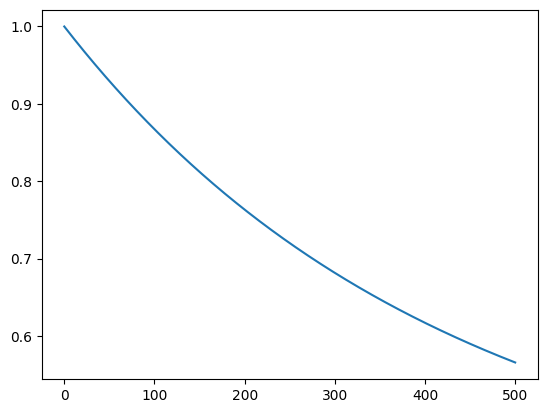

In [19]:
fig, ax = plt.subplots()
# can change the data in the ax function to compare fids in order to get results for the fids
# data = []
# for i in range(len(compare_state)):
#     data.append(compare_state[i][7, 7])
ax.plot(time, compare_fids)

# fitting the data
def function_fit(t, b):
    return np.exp(-t / b)

# parameters, covariance = curve_fit(function_fit, time, data)

# fit_func = function_fit(time, parameters[0])
# ax.plot(time, fit_func, color = "black", linestyle = "-", label = "fitted line")
# # plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


# T1_idle = parameters[0]
# print(parameters[0]) 

In [20]:
compare_fids[-1]

0.5656383891763793

In [21]:
def stabilizer(initial_state, checked_state, time_list):
    states = []
    fids = []


    # run the circuit 
    initial_time = time_list[0]
    initial_state_relax = trotter.apply(initial_state, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
    for i in range(len(initial_state_relax)):
        a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
        states.append(hada_layer * initial_state_relax[i] * hada_layer.dag()) # storing the state in the computational basis 
        fids.append(qt.fidelity(a, checked_state))

    # now apply the cnots to the circuit 
    cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

    rho_hada_pre_cnot = hada_layer * initial_state_relax[-1] * hada_layer.dag()

    syndrome_time = time_list[1]
    after_syndrome_extraction = trotter.apply(rho_hada_pre_cnot, duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    for i in range(len(after_syndrome_extraction)):
        a = hada_layer * after_syndrome_extraction[i] * hada_layer.dag() # need to do this in order to get the right fidelity in the correct basis 
        a = qt.ptrace(a, [0, 1, 2])
        states.append(after_syndrome_extraction[i])
        fids.append(qt.fidelity(a, checked_state))

    
    # apply the recovery gate
    # measurement step is instantaneous 
    rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
    rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
    rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
    rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

    # now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
    # correction_operators
    r00 = qt.tensor(qt.qeye(dim ** N))
    r01 = qt.Qobj((qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim ** 3))).full())
    r10 = qt.Qobj((qt.tensor(z_gate, qt.qeye(dim ** 4))).full())
    r11 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.qeye(dim ** 2))).full())

    recovery_time = time_list[2]

    # putting the states in the hadamard basis 
    rho00 = hada_layer * rho00 * hada_layer.dag()
    rho01 = hada_layer * rho01 * hada_layer.dag()
    rho10 = hada_layer * rho10 * hada_layer.dag()
    rho11 = hada_layer * rho11 * hada_layer.dag()
    # measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
    recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
    # states.extend(recovery1)
    # fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
    recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
    recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
    recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

    # have to add them back to get the overall density matrix 
    for i in range(len(recovery1)):
        total_state = (np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag()) * recovery1[i] + 
                    np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag()) * recovery2[i] + 
                    np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag()) * recovery3[i] + 
                    np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag()) * recovery4[i])
        total_state_normal = total_state / np.trace(total_state)
        total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
        fids.append(qt.fidelity(total_state_trace, checked_state))
        total_state_normal = hada_layer * total_state_normal * hada_layer.dag() # doing this in order to put the state in the computational basis 
        states.append(total_state_normal)

    # total_time = recovery_time + syndrome_time + initial_time

    return states, fids


In [22]:
result_states = []
result_fids = []

time_list = [.34, .02, .05]

# doing stabilizers for multiple iterations
iterations = 1191
iter_list = [] # for graphing purposes 

# rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# building the data
for i in tqdm(range(iterations)):
    iter_list.append(i)
    a, b = stabilizer(initial_state=rho_encoded, checked_state=rho_encoded_traced, time_list=time_list)
    c = b[-1]
    result_states.extend(a)
    result_fids.append(c)
    rho_encoded = hada_layer * result_states[-1] * hada_layer.dag()

  0%|          | 5/1191 [00:00<00:59, 19.81it/s]

100%|██████████| 1191/1191 [00:30<00:00, 39.45it/s]


In [23]:
# create the list of time for the amount of iterations
total_time = iterations * sum(time_list)

time_plot = np.linspace(0, total_time, len(result_states))

# analyze the data
plotted_fids = []
for i in range(int(len(result_fids) / 4)):
    plotted_fids.append(result_fids[i * 4 + 3])  

# trace out the ancillas
state_sim = []
for i in range(len(result_states)):
    state_sim.append(qt.ptrace(result_states[i], [0, 1, 2]))

In [25]:
# # plot the fids 
# fig, ax = plt.subplots()
# ax.plot(time_plot, result_fids)

# parameters, covariance = curve_fit(function_fit, time_plot, result_fids)

# fit_func = function_fit(time, parameters[0])
# ax.plot(time, fit_func, color = "black", linestyle = "-", label = "fitted line")
# # plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


# T1_idle = parameters[0]
# print(parameters[0]) 

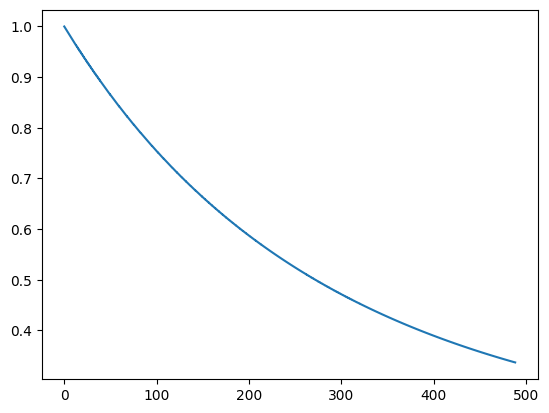

In [26]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_sim)):
    data.append(state_sim[i][7, 7])
ax.plot(time_plot, data)

In [27]:
# this means that this bit flip code is obviously better
# need to understand a few things about the basis in order to make it make sense 

In [28]:
# there is an improvement but need to study it a bit but the plots are done
# try doing this with the gates that are biased this should be really easy

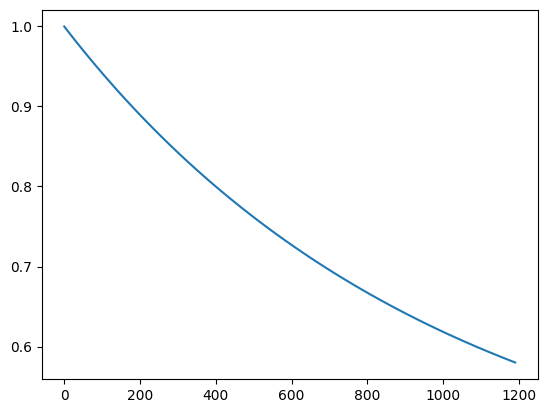

In [29]:
# plot the fids 
fig, ax = plt.subplots()
ax.plot(iter_list, result_fids)

In [30]:
result_fids[-1]

0.5802524946289093